# Почему GaussianNB хуже Logistic Regression?

Цель: понять, почему GNB показывает logloss ~0.79, а LR ~0.60.

Анализируем:
1. Распределения признаков (нормальность)
2. Корреляции между признаками (условная независимость)
3. Масштаб признаков (GNB чувствителен)
4. Class-conditional распределения (предположение GNB)
5. Сравнение качества GNB vs LR

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

## 1. Подготовка данных (из Untitled.ipynb)

In [2]:
import re

def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", "", parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()

def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", "", parts[0])
    init = re.sub(r"[^a-z]", "", parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()

ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

joined = tml.merge(ods, how='inner', on=['week', 'p1', 'p2'], suffixes=('_tml', '_ods'))
print('joined shape:', joined.shape)

joined shape: (17633, 99)


In [3]:
# Build features
joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['loser_key'] = joined['loser_name'].map(key_from_tml)
joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

joined['rank_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank'], joined['loser_rank'])
joined['rank_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank'], joined['loser_rank'])
joined['rank_diff_p1_minus_p2'] = joined['rank_p1'] - joined['rank_p2']

joined['rank_points_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_diff_p1_minus_p2'] = joined['rank_points_p1'] - joined['rank_points_p2']

joined['ps_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['PSW'], joined['PSL'])
joined['ps_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['PSW'], joined['PSL'])

p1 = 1.0 / joined['ps_odds_p1']
p2 = 1.0 / joined['ps_odds_p2']
s = p1 + p2
joined['ps_imp_p1'] = p1 / s

# Fill NaN for modeling
for c in ['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']:
    if c in joined.columns:
        joined[c] = joined[c].fillna(joined[c].median())

print('Features ready')

Features ready


## 2. Распределения признаков и проверка нормальности

In [4]:
features = ['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']
df = joined[features + ['y_p1_win', 'week']].dropna()

print('=== Distribution analysis ===')
for f in features:
    x = df[f].dropna()
    stat, pval = stats.normaltest(x.sample(min(5000, len(x)), random_state=42))
    print(f'{f}:')
    print(f'  mean={x.mean():.4f}, std={x.std():.4f}')
    print(f'  skew={stats.skew(x):.4f}, kurtosis={stats.kurtosis(x):.4f}')
    print(f'  normaltest p-value={pval:.4e} (p<0.05 => not normal)')
    print()

=== Distribution analysis ===
ps_imp_p1:
  mean=0.4961, std=0.2135
  skew=0.0086, kurtosis=-0.7472
  normaltest p-value=3.1921e-76 (p<0.05 => not normal)

rank_diff_p1_minus_p2:
  mean=-1.1929, std=125.7239
  skew=0.2857, kurtosis=31.3039
  normaltest p-value=0.0000e+00 (p<0.05 => not normal)

rank_points_diff_p1_minus_p2:
  mean=-79.4477, std=2164.2373
  skew=-0.0040, kurtosis=6.3515
  normaltest p-value=1.7061e-144 (p<0.05 => not normal)



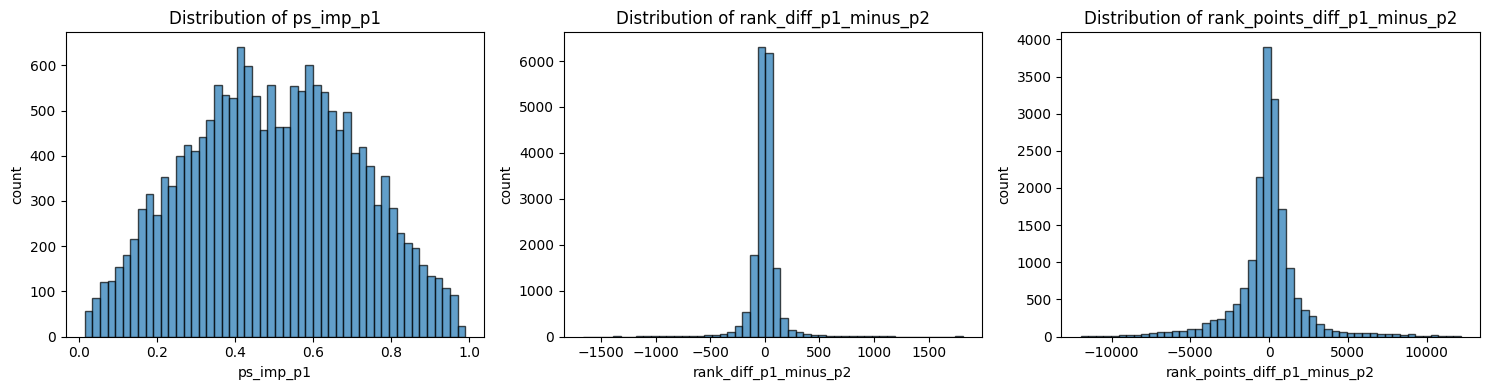

In [5]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, features):
    ax.hist(df[f], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel(f)
    ax.set_ylabel('count')
    ax.set_title(f'Distribution of {f}')
plt.tight_layout()
plt.savefig('figures/gnb_feature_distributions.png', dpi=150)
plt.show()

## 3. Корреляции между признаками (нарушение условной независимости)

=== Correlation matrix ===
                              ps_imp_p1  rank_diff_p1_minus_p2  \
ps_imp_p1                      1.000000              -0.518834   
rank_diff_p1_minus_p2         -0.518834               1.000000   
rank_points_diff_p1_minus_p2   0.712265              -0.385301   

                              rank_points_diff_p1_minus_p2  
ps_imp_p1                                         0.712265  
rank_diff_p1_minus_p2                            -0.385301  
rank_points_diff_p1_minus_p2                      1.000000  


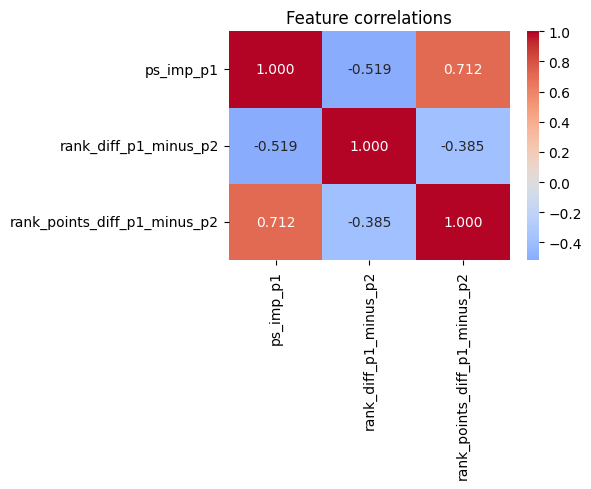

In [6]:
print('=== Correlation matrix ===')
corr = df[features].corr()
print(corr)

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Feature correlations')
plt.tight_layout()
plt.savefig('figures/gnb_feature_correlations.png', dpi=150)
plt.show()

## 4. Масштаб признаков (GNB чувствителен к масштабу)

In [7]:
print('=== Scale comparison ===')
for f in features:
    x = df[f].dropna()
    print(f'{f}: min={x.min():.2f}, max={x.max():.2f}, range={x.max()-x.min():.2f}, std={x.std():.2f}')

=== Scale comparison ===
ps_imp_p1: min=0.02, max=0.99, range=0.97, std=0.21
rank_diff_p1_minus_p2: min=-1668.00, max=1815.00, range=3483.00, std=125.72
rank_points_diff_p1_minus_p2: min=-11967.00, max=12177.00, range=24144.00, std=2164.24


## 5. Class-conditional распределения (предположение GNB)

In [8]:
print('=== Class-conditional distributions ===')
for f in features:
    x0 = df.loc[df['y_p1_win']==0, f].dropna()
    x1 = df.loc[df['y_p1_win']==1, f].dropna()
    print(f'{f}:')
    print(f'  y=0: mean={x0.mean():.4f}, std={x0.std():.4f}')
    print(f'  y=1: mean={x1.mean():.4f}, std={x1.std():.4f}')
    print()

=== Class-conditional distributions ===
ps_imp_p1:
  y=0: mean=0.4036, std=0.1937
  y=1: mean=0.5874, std=0.1919

rank_diff_p1_minus_p2:
  y=0: mean=26.6480, std=122.3454
  y=1: mean=-28.6543, std=122.9476

rank_points_diff_p1_minus_p2:
  y=0: mean=-733.1946, std=2101.4101
  y=1: mean=565.3881, std=2027.6412



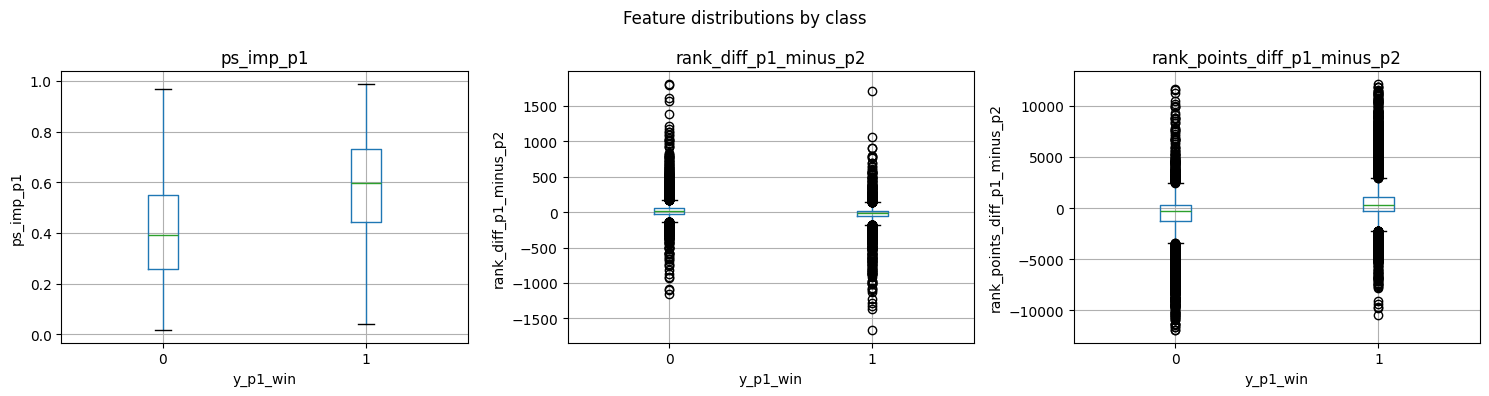

In [9]:
# Boxplots by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, features):
    df.boxplot(column=f, by='y_p1_win', ax=ax)
    ax.set_xlabel('y_p1_win')
    ax.set_ylabel(f)
plt.suptitle('Feature distributions by class')
plt.tight_layout()
plt.savefig('figures/gnb_features_by_class.png', dpi=150)
plt.show()

## 6. Сравнение GNB vs LR на train/test

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

# Time-based split
cutoff = pd.Timestamp('2024-01-01')
train_df = df[df['week'] < cutoff].copy()
test_df = df[df['week'] >= cutoff].copy()

X_train = train_df[features]
y_train = train_df['y_p1_win']
X_test = test_df[features]
y_test = test_df['y_p1_win']

print(f'train: {len(train_df)}, test: {len(test_df)}')

train: 14098, test: 3535


In [11]:
# GNB (raw features)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
p_gnb = gnb.predict_proba(X_test)[:, 1]

# LR (raw features)
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
p_lr = lr.predict_proba(X_test)[:, 1]

# LR (scaled features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_scaled = LogisticRegression(max_iter=2000)
lr_scaled.fit(X_train_scaled, y_train)
p_lr_scaled = lr_scaled.predict_proba(X_test_scaled)[:, 1]

# Results
def eval_metrics(y_true, p_pred, name):
    return {
        'model': name,
        'logloss': log_loss(y_true, p_pred),
        'roc_auc': roc_auc_score(y_true, p_pred),
        'acc@0.5': accuracy_score(y_true, p_pred >= 0.5),
    }

results = [
    eval_metrics(y_test, p_gnb, 'GaussianNB (raw)'),
    eval_metrics(y_test, p_lr, 'LogisticRegression (raw)'),
    eval_metrics(y_test, p_lr_scaled, 'LogisticRegression (scaled)'),
]

results_df = pd.DataFrame(results)
print('=== Model comparison ===')
print(results_df)

=== Model comparison ===
                         model   logloss   roc_auc   acc@0.5
0             GaussianNB (raw)  0.651582  0.728555  0.671004
1     LogisticRegression (raw)  0.601269  0.737093  0.672702
2  LogisticRegression (scaled)  0.601414  0.736844  0.668458


## 7. Выводы

Ожидаемые причины почему GNB хуже LR:

1. **Ненормальность распределений**: GNB предполагает нормальность, но признаки (особенно rank_diff, rank_points_diff) имеют тяжёлые хвосты.

2. **Корреляции между признаками**: GNB предполагает условную независимость, но ps_imp_p1 коррелирует с rank_diff и rank_points_diff.

3. **Масштаб**: GNB чувствителен к масштабу, а признаки имеют сильно разные диапазоны (ps_imp_p1: 0-1, rank_diff: -500..+500, rank_points_diff: -10000..+10000).

4. **LR более робастен**: не требует нормальности, устойчив к корреляциям (при отсутствии сильной мультиколлинеарности), инвариантен к масштабу при наличии регуляризации.